# 35 — Sharing posteriors vs raw observations

**Why this notebook exists (Plan P6).** In the population model a peer is an external source
the receiver trusts (precision $\pi_s$). But *what* does it transmit? The paper keeps this an
explicit axis, "because sharing conclusions propagates bias along with signal":

* **`sharing_mode='posterior'`** (default) — peers transmit their *whole* belief net and the
  receiver fuses by precision addition. A conclusion propagates, **prior bias included**.
* **`sharing_mode='observation'`** — peers transmit only their *raw observations* (per-step
  Fisher deposits). Each agent keeps its own prior and pools neighbours' data, so the
  **signal** propagates but the **bias** does not.

Same trust graph $W$ in both — they differ only in what crosses it. We test it with a bloc of
stubborn, high-precision **phlogiston zealots** (a false belief held as pure prior, the world
being oxygen) wired to ordinary **truth-seekers**, and ask whether the zealots' bias infects
the seekers.

In [1]:
%matplotlib inline
import sys, pathlib, dataclasses
ROOT = pathlib.Path.cwd()
sys.path.insert(0, str(ROOT if (ROOT / 'src').exists() else ROOT.parent))
import numpy as np, jax
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})

from src.structural.phlogiston import StructuralConfig
from src.structural import step as S, graphs as G, shells

KEY = jax.random.PRNGKey(0)
N, N_ZEAL = 40, 20

def run(mode, n_steps=90):
    g = G.complete(N)
    cfg = dataclasses.replace(StructuralConfig(), n_agents=N, n_steps=n_steps, t_shift=0,
        observation_operator='relational', precision_mode='derived', sharing_mode=mode)
    groups = [{"count": N_ZEAL, "paradigm": "phlogiston", "stance": cfg.mu_phlog_mass, "prec_scale": 300.0},
              {"count": N - N_ZEAL, "paradigm": "phlogiston", "stance": cfg.mu_phlog_mass, "prec_scale": 1.0}]
    st = S.init_state(cfg, KEY, groups=groups, W_override=g.trust_W())
    idx_t = np.asarray(S.run_trace_index(cfg, st))             # (T, N)
    Pi_t, _ = S.run_trace_net(cfg, st)
    return (idx_t[:, :N_ZEAL].mean(1), idx_t[:, N_ZEAL:].mean(1),
            shells.residual_disagreement(Pi_t))

zeal_p, seek_p, resid_p = run('posterior')
zeal_o, seek_o, resid_o = run('observation')
print('world = oxygen (truth). zealots = 300x phlogiston prior (pure bias).')

world = oxygen (truth). zealots = 300x phlogiston prior (pure bias).


## §1 — The contamination contrast

Both panels: the same zealot bloc and the same seekers on the same complete graph. Left, peers
share **conclusions** (posterior fusion): the zealots' high-precision bias dominates the fuse
and drags the seekers off the truth — one *contaminated consensus*. Right, peers share **raw
observations**: the seekers pool the zealots' (oxygen-world) data, never their prior, and reach
the truth — the zealots stay wrong, but their bias is quarantined.

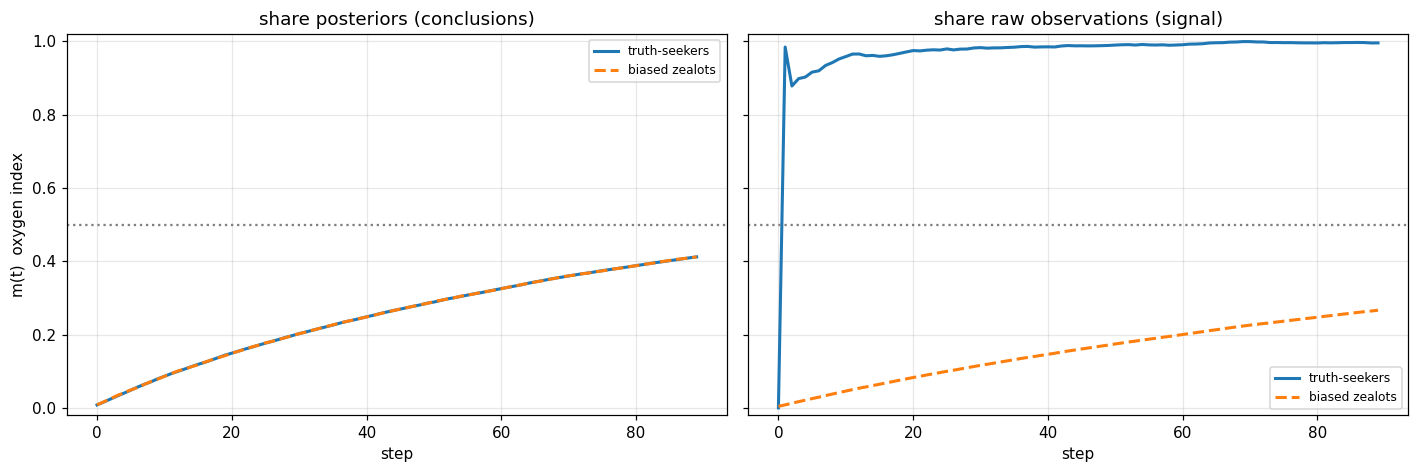

seekers' final belief | posterior: 0.41 (dragged off truth)   observation: 1.00 (reached truth)
=> the zealots' prior bias propagates ONLY when whole beliefs (conclusions) are shared.


In [2]:
fig, (a0, a1) = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)
for ax, (zeal, seek), ttl in [(a0, (zeal_p, seek_p), "share posteriors (conclusions)"),
                              (a1, (zeal_o, seek_o), "share raw observations (signal)")]:
    ax.plot(seek, lw=2, label='truth-seekers')
    ax.plot(zeal, lw=2, ls='--', label='biased zealots')
    ax.axhline(0.5, color='grey', ls=':'); ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel('step'); ax.set_title(ttl); ax.legend(fontsize=8)
a0.set_ylabel('m(t)  oxygen index')
plt.tight_layout(); plt.savefig('figures_nb35_contamination.png'); plt.show()
print(f"seekers' final belief | posterior: {seek_p[-1]:.2f} (dragged off truth)   "
      f"observation: {seek_o[-1]:.2f} (reached truth)")
print(f"=> the zealots' prior bias propagates ONLY when whole beliefs (conclusions) are shared.")

## §2 — The honest trade-off: consensus vs accuracy

Sharing conclusions buys *consensus* (everyone ends in the same place) at the cost of carrying
bias; sharing observations buys *accuracy for the open-minded* at the cost of leaving the
zealots unconverted — so the population stays structurally split (higher residual
disagreement). Neither is strictly better; the curator's choice of channel decides which
failure you get.

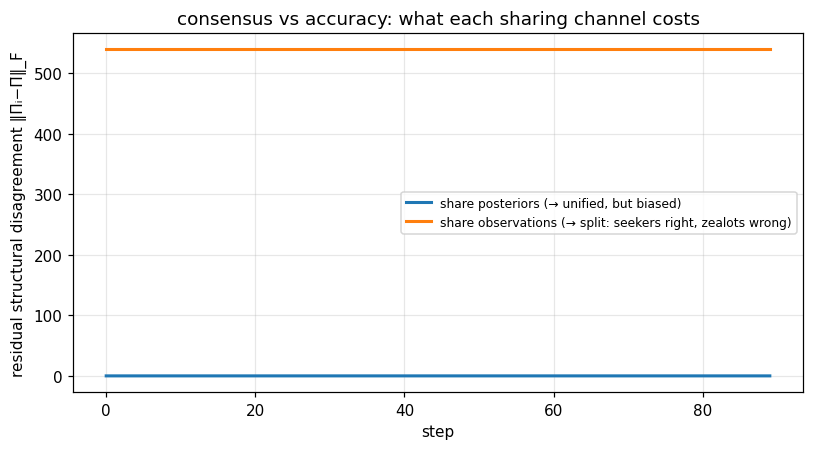

final residual disagreement | posterior: 0.0 (consensus)   observation: 539.0 (split)
final spread seekers-vs-zealots | posterior: 0.00   observation: 0.73


In [3]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(resid_p, lw=2, label='share posteriors (→ unified, but biased)')
ax.plot(resid_o, lw=2, label='share observations (→ split: seekers right, zealots wrong)')
ax.set_xlabel('step'); ax.set_ylabel('residual structural disagreement ‖Πᵢ−Π̄‖_F')
ax.set_title('consensus vs accuracy: what each sharing channel costs')
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig('figures_nb35_tradeoff.png'); plt.show()
print(f"final residual disagreement | posterior: {resid_p[-1]:.1f} (consensus)   "
      f"observation: {resid_o[-1]:.1f} (split)")
print(f"final spread seekers-vs-zealots | posterior: {abs(seek_p[-1]-zeal_p[-1]):.2f}   "
      f"observation: {abs(seek_o[-1]-zeal_o[-1]):.2f}")

## Verdict

The sharing axis is wired (`cfg.sharing_mode`) and one cfg flag flips what crosses the trust
graph. The mechanism is exactly the paper's: **sharing conclusions propagates bias along with
signal**. A bloc of stubborn high-precision zealots — a false belief held as pure prior —
contaminates the truth-seekers into a single wrong consensus *only* under posterior-fusion
(§1); when only raw observations are pooled, the seekers reach the truth and the bias is
quarantined, at the price of leaving the zealots unconverted and the population split (§2).
This is the distinction the scalar models cannot draw, and the reason the paper keeps "share
posteriors or raw observations" as an explicit experimental axis rather than a buried default.